# Plot Figures 1 and S1

This code plots maps of the monthly precipitation climatology, and month-to-month differences for HR-ERA5/IMERG (Figure 1) and LR-ERA5/IMERG and LR-ERA5/GPCP (Figure S1). 

## Import Necessary Packages

In [2]:
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
from scipy import stats
from calendar import month_name
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':300,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

## User-Defined Configurations

Specify the directory where the P-$B_L$ datasets are, and set the directory where the figures will be saved. Define the latitude/longitude bounds for the full domain and our subregions of interest. Specify "monthly pairs" for precipitation analysis (i.e., `MONTHPAIRS = [(6,7),(7,8)]` for June-to-July and July-to-August changes). Set the confidence level for our statistical significance analysis.

In [3]:
FILEDIR    = '/global/cfs/cdirs/m4334/sferrett/monsoon-pod/data/interim'
SAVEDIR    = '/global/cfs/cdirs/m4334/sferrett/monsoon-pod/figs'
REGIONS    = {'Eastern Arabian Sea':{'latmin':9.,'latmax':19.5,'lonmin':64.,'lonmax':72.}, 
              'Central India':{'latmin':18.,'latmax':24.,'lonmin':76.,'lonmax':83.},
              'Central Bay of Bengal':{'latmin':9.,'latmax':14.5,'lonmin':86.5,'lonmax':90.},
              'Equatorial Indian Ocean':{'latmin':5.,'latmax':10.,'lonmin':62.,'lonmax':67.5},
              'Konkan Coast':{'latmin':15.,'latmax':19.5,'lonmin':69.,'lonmax':72.5}} 
LATRANGE   = (5.,25.)
LONRANGE   = (60.,90.)
MONTHPAIRS = [(6,7),(7,8)]
CONFIDENCE = 0.95

## Load Baseline Datasets

Load in precipitation from each baseline dataset (stored in `FILEDIR`).

In [4]:
def load(filename,filedir=FILEDIR,varlist=None):
    filepath = f'{filedir}/{filename}'
    ds = xr.open_dataset(filepath)
    if varlist:
        ds = ds[varlist]
    return ds.load()

In [5]:
hrimerg = load('HR_ERA5_IMERG_baseline.nc',varlist=['pr'])
lrimerg = load('LR_ERA5_IMERG_baseline.nc',varlist=['pr'])
lrgpcp  = load('LR_ERA5_GPCP_baseline.nc',varlist=['pr'])

## Functions for Analysis and Plotting

The `calc_monthly_pr_change()` function computes the monthly precipitation climatology for each month in a given dataset and calculates the change in precipitation between specified pairs of months from `MONTHPAIRS`. The `get_sig_masks()` function determines where these monthly precipitation changes are statistically significant relative to interannual variability. It uses a two-tailed paired *t*-test to create boolean masks where `True` values indicate statistically significant changes, based on a confidence level specified by `CONFIDENCE`.

In [6]:
def calc_monthly_pr_change(data,monthpairs=MONTHPAIRS):
    monthlypr = data.groupby('time.month').mean(dim='time')
    prchanges = []
    for startmonth,endmonth in monthpairs:
        prchange = monthlypr.sel(month=endmonth)-monthlypr.sel(month=startmonth)
        prchanges.append(prchange)
    return monthlypr,prchanges

def get_sig_masks(data,monthpairs=MONTHPAIRS,confidence=CONFIDENCE):
    sigmasks = []
    for startmonth,endmonth in monthpairs:
        start = data.sel(time=data['time.month']==startmonth).groupby('time.year').mean(dim='time')
        end   = data.sel(time=data['time.month']==endmonth).groupby('time.year').mean(dim='time')
        tstat,pval = stats.ttest_rel(end.values,start.values,axis=0)
        sigmask = pval<(1-confidence)
        sigmask = xr.DataArray(sigmask,coords={'lat':start.lat,'lon':start.lon},dims=['lat','lon'])
        sigmasks.append(sigmask)
    return sigmasks

Both functions below process loaded data, perform required analyses, and generate formatted figures with plotted results. While `create_plot()` focuses on producing the main text figure using the high-resolution dataset, `create_si_plot()` is designed to format and display results from the two low-resolution datasets for the Supplemental Information.

In [7]:
def create_plot(data,latrange=LATRANGE,lonrange=LONRANGE,regions=REGIONS,monthpairs=MONTHPAIRS,confidence=CONFIDENCE,filename=None):
    fig,axs = pplt.subplots([[1,1,2,2,3,3],[0,4,4,5,5,0]],abc=True,proj='cyl',figwidth=6.5,hspace=3)
    axs.format(grid=False,coast=True,coastlinewidth=1,latlim=latrange,latlines=[10,15,20],lonlim=lonrange,lonlines=5,lonlabels=True)
    monthlypr,prchanges = calc_monthly_pr_change(data,monthpairs)
    sigmasks = get_sig_masks(data,monthpairs,confidence)
    for i,month in enumerate(monthlypr.month.values):
        ax = axs[i]
        ax.format(titleloc='l',title=f'{month_name[month]}',latlabels=(i==0))
        m = ax.contourf(monthlypr.sel(month=month),cmap='ColdHot_r',cmap_kw={'left':0.5},vmin=0,vmax=18,levels=15,extend='max')
    for i,(prchange,sigmask,(startmonth,endmonth)) in enumerate(zip(prchanges,sigmasks,monthpairs)):
        ax = axs[i+3]
        ax.format(titleloc='l',title=f'{month_name[endmonth]} $-$ {month_name[startmonth]}',latlabels=(i==0))
        n = ax.contourf(prchange,cmap='ColdHot_r',vmin=-9,vmax=9,levels=22,extend='both')
        ax.contour(prchange,color='k',levels=[0],linewidth=0.5)
        ax.contourf(~sigmask,colors='none',levels=[0,0.5,1],hatches=['','///'])
    for i,coords in enumerate(list(regions.values())):
        j = 3 if i<3 else 4
        axs[j].add_patch(patches.Rectangle((coords['lonmin'],coords['latmin']),coords['lonmax']-coords['lonmin'],coords['latmax']-coords['latmin'],edgecolor='k',facecolor='none',linewidth=1))
    cax1 = inset_axes(axs[2],width='12%',height='100%',loc='lower left',bbox_to_anchor=(1.04,0,1,1),bbox_transform=axs[2].transAxes,borderpad=0)
    cax2 = inset_axes(axs[4],width='12%',height='100%',loc='lower left',bbox_to_anchor=(1.04,0,1,1),bbox_transform=axs[4].transAxes,borderpad=0)
    cb1 = fig.colorbar(m,cax=cax1,label='Precipitation (mm/day)',ticks=[0,3,6,9,12,15,18],extendfrac=0.15)
    cb2 = fig.colorbar(n,cax=cax2,label='$\Delta$Precipitation (mm/day)',ticks=[-9,-6,-3,0,3,6,9],extendfrac=0.15)
    cb1.ax.minorticks_off()
    cb2.ax.minorticks_off()
    pplt.show()
    if filename:
        fig.save(f'{SAVEDIR}/{filename}',bbox_inches='tight',pad_inches=0.02)

def create_si_plot(datadict,latrange=LATRANGE,lonrange=LONRANGE,regions=REGIONS,monthpairs=MONTHPAIRS,confidence=CONFIDENCE,filename=None):
    datalist = [item[0] for item in datadict]
    namelist = [item[1] for item in datadict]
    fig,axs = pplt.subplots(nrows=len(datalist),ncols=len(regions),proj='cyl',figwidth=6.5,space=0,tight=True)
    axs.format(grid=False,rowlabels=namelist,coast=True,coastlinewidth=1,latlim=latrange,latlines=[10,15,20],lonlim=lonrange,lonlines=5)
    axs[:,0].format(latlabels=True)
    axs[-1,:].format(lonlabels=True)
    for i,data in enumerate(datalist):
        monthlypr,prchanges = calc_monthly_pr_change(data,monthpairs)
        sigmasks = get_sig_masks(data,monthpairs,confidence)
        for j,month in enumerate(monthlypr.month.values):
            ax = axs[i,j]
            a = ax.contourf(monthlypr.sel(month=month),cmap='ColdHot_r',cmap_kw={'left':0.5},vmin=0,vmax=18,levels=15,extend='max')
        if i==0:
            titles = ['June','July','August','July $-$ June','August $-$ July']
            for j,title in enumerate(titles):
                axs[i,j].format(title=title)
        for j,(prchange,sigmask,(startmonth,endmonth)) in enumerate(zip(prchanges,sigmasks,monthpairs)):
            ax = axs[i,j+3]
            b = ax.contourf(prchange,cmap='ColdHot_r',vmin=-9,vmax=9,levels=22,extend='both')
            ax.contour(prchange,color='k',levels=[0],linewidth=0.5)
            ax.contourf(~sigmask,colors='none',levels=[0,0.5,1],hatches=['','///'])
        for j,coords in enumerate(list(regions.values())):
            k = 3 if j<3 else 4
            axs[i,k].add_patch(patches.Rectangle(
                (coords['lonmin'],coords['latmin']),coords['lonmax']-coords['lonmin'],coords['latmax']-coords['latmin'],
                edgecolor='k',facecolor='none',linewidth=1))
    fig.colorbar(a,loc='b',cols=(1,3),label='Precipitation (mm/day)',ticks=3)
    fig.colorbar(b,loc='b',cols=(4,5),label='$\Delta$Precipitation (mm/day)',ticks=3)
    pplt.show()
    if filename:
        fig.save(f'{SAVEDIR}/{filename}')

## Plot and Save Figures

Execute plotting, and save the figures to `SAVEDIR`.

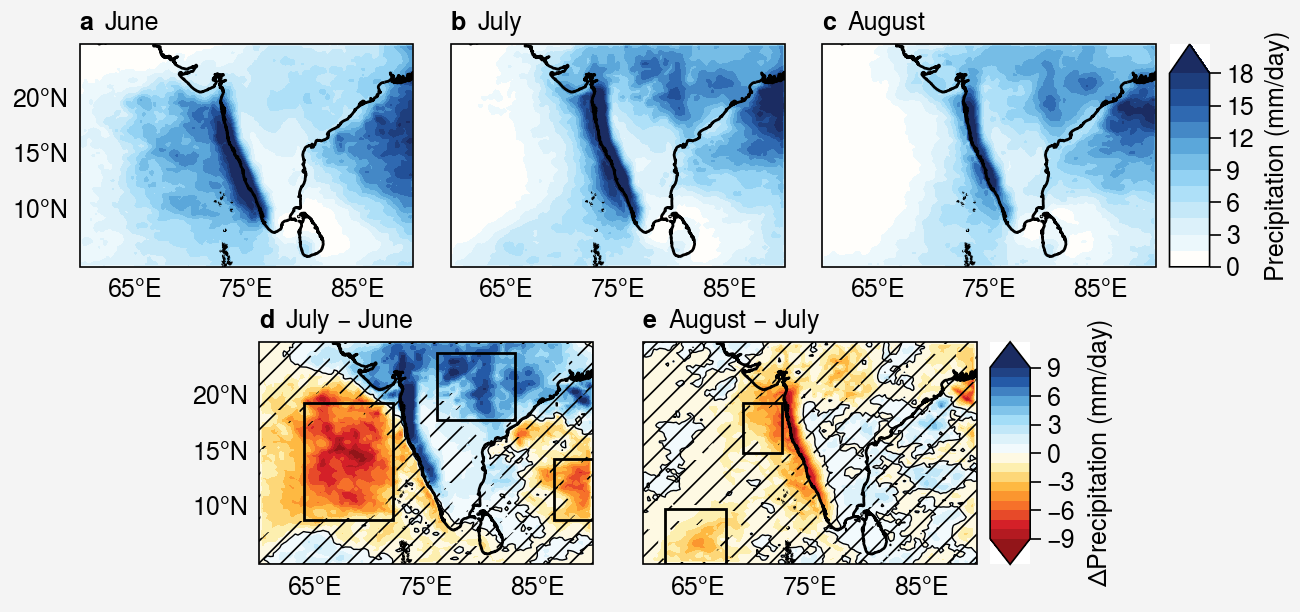

In [8]:
create_plot(hrimerg.pr,filename='fig_1.jpg')

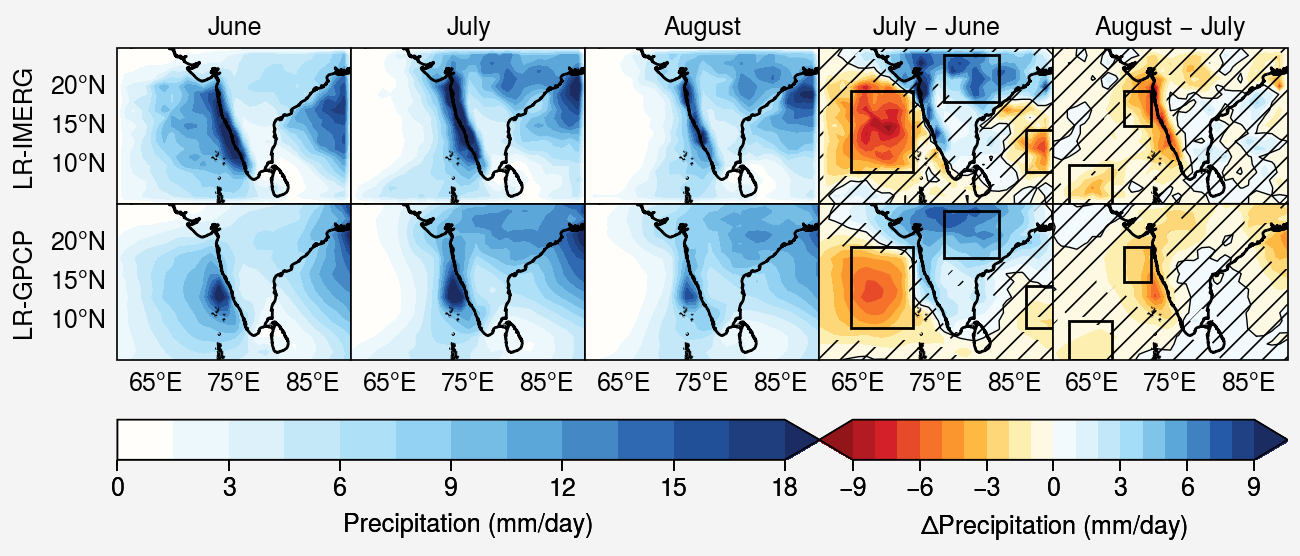

In [9]:
datadict = [
    (lrimerg.pr,'LR-IMERG'),
    (lrgpcp.pr,'LR-GPCP')]
create_si_plot(datadict,filename='fig_S1.jpg')